In [148]:
# Import librării
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV, KFold

In [149]:
df=pd.read_csv("house_2.csv")


In [150]:
df.head()

,Price,Bedroom,Space,Room,Lot,Tax,Bathroom,Garage,Condition
0,53.0,2.0,967.0,5.0,39.0,652.0,1.5,0.0,0.0
1,55.0,2.0,815.0,5.0,33.0,1000.0,1.0,2.0,1.0
2,56.0,3.0,900.0,5.0,35.0,897.0,1.5,1.0,0.0
3,58.0,3.0,1007.0,6.0,24.0,964.0,1.5,2.0,0.0
4,64.0,3.0,1100.0,7.0,50.0,1099.0,1.5,1.5,0.0


In [151]:
print("Coloane:", df.columns.tolist())

Coloane: ['Price', 'Bedroom', 'Space', 'Room', 'Lot', 'Tax', 'Bathroom', 'Garage', 'Condition']


In [152]:
print("Dimensiune DataFrame:",df.shape)

Dimensiune DataFrame: (157, 9)


In [153]:
print("===== Tipurile de date =====")
df.dtypes

===== Tipurile de date =====


Price        float64
Bedroom      float64
Space        float64
Room         float64
Lot          float64
Tax          float64
Bathroom     float64
Garage       float64
Condition    float64
dtype: object

In [154]:
# Informații despre coloane, tipuri de date și valori lipsă
print("===== Rezumat DataFrame =====")
df.info()

===== Rezumat DataFrame =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Price      156 non-null    float64
 1   Bedroom    156 non-null    float64
 2   Space      146 non-null    float64
 3   Room       156 non-null    float64
 4   Lot        146 non-null    float64
 5   Tax        147 non-null    float64
 6   Bathroom   156 non-null    float64
 7   Garage     156 non-null    float64
 8   Condition  156 non-null    float64
dtypes: float64(9)
memory usage: 11.2 KB


Acest set de date contine doar variabile numerice, de tip float. Setul de date conține informații despre prețurile caselor din Chicago și caracteristicile acestora, fiind introduse diverse coloane. Variabila tinta in acest caz este coloana Price. Se observa faptul ca exista valori lipsa, ceea ce inseamna ca setul de date va trebui curatat.


In [155]:
# Verificarea valorilor lipsă 
missing_values =df.isna().sum()
if missing_values.sum() > 0:
    print("Valori lipsă pe coloană:")
    print(missing_values[missing_values > 0])
else:
    print("Nu există valori lipsă în setul de date.")

Valori lipsă pe coloană:
Price         1
Bedroom       1
Space        11
Room          1
Lot          11
Tax          10
Bathroom      1
Garage        1
Condition     1
dtype: int64


In [156]:
df.nunique()

Price         47
Bedroom        7
Space        137
Room           7
Lot           11
Tax          138
Bathroom       5
Garage         4
Condition      2
dtype: int64

Coloanele categoriale sunt: Garage si Condition.

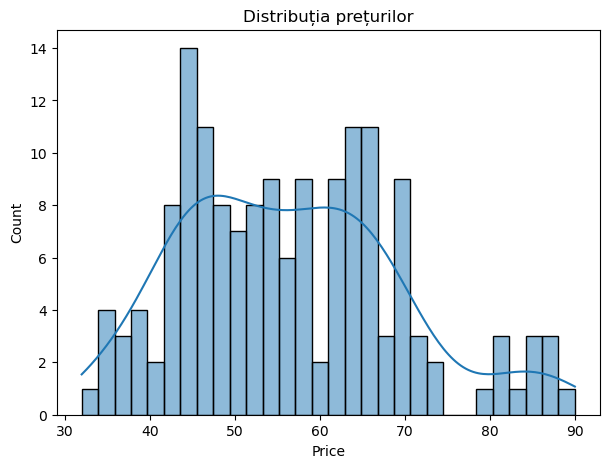

In [157]:
# Distribuția variabilei țintă (MEDV - prețul median al locuințelor)
# Setearea dimensiunii figurii pentru grafic
plt.figure(figsize=(7,5))  

# Crearea unei histograme cu curba de densitate (KDE) pentru variabila țintă MEDV
sns.histplot(df['Price'], kde=True, bins=30)  

# Adăugarea titlului pentru grafic
plt.title('Distribuția prețurilor')  

# Afișare grafic
plt.show()  


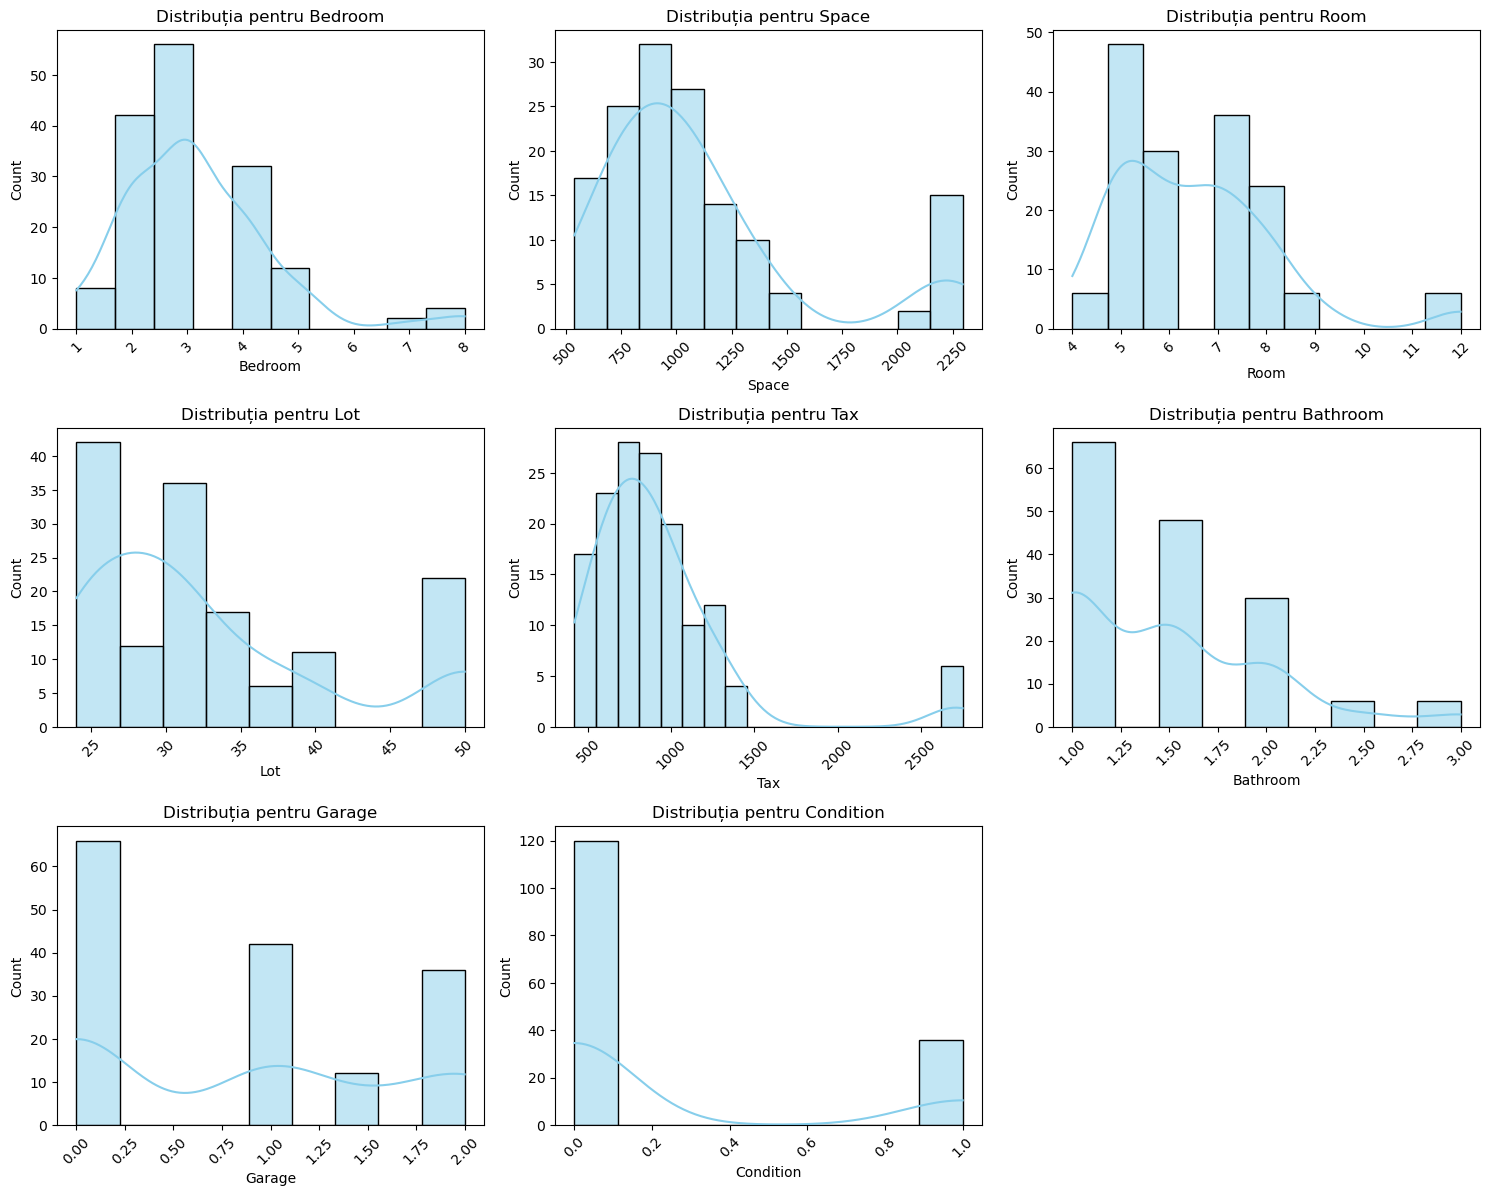

In [158]:
# Distribuția tuturor variabilelor

# Selectarea coloanelor numerice
df_plot=df.drop('Price', axis=1)
num_cols = df_plot.select_dtypes(include=[np.number]).columns

# Setare subgraficului
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten()

# Creare distplot pentru fiecare coloană numerică
for i, col in enumerate(num_cols):
    sns.histplot(df_plot[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribuția pentru {col}")
    axes[i].tick_params(axis='x', rotation=45)

# Ascunderea subploturilor goale
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [159]:
# Numără valorile True și False din coloana 'job_work_from_home'
garage = df['Garage'].value_counts()

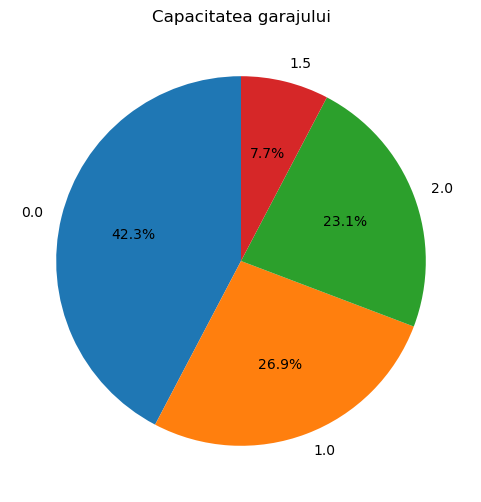

In [160]:
# Desenează graficul circular
plt.figure(figsize=(6,6))  # Setează dimensiunea figurii

plt.pie(
    garage, 
    labels=garage.index,  # Etichete pentru segmente
    autopct='%1.1f%%',         # Afișează procentajul fiecărui segment
    startangle=90              # Începe graficul de la 90 de grade
)

plt.title('Capacitatea garajului')  # Titlul graficului
plt.show()                                # Afișează graficul


In [161]:
# Numără valorile True și False din coloana 'job_work_from_home'
condition = df['Condition'].value_counts()

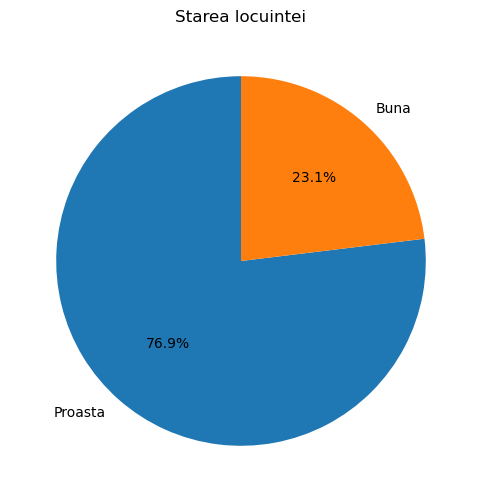

In [162]:
# Desenează graficul circular
plt.figure(figsize=(6,6))  # Setează dimensiunea figurii

plt.pie(
    condition, 
    labels=['Proasta','Buna'],  # Etichete pentru segmente
    autopct='%1.1f%%',         # Afișează procentajul fiecărui segment
    startangle=90              # Începe graficul de la 90 de grade
)

plt.title('Starea locuintei')  # Titlul graficului
plt.show()                                # Afișează graficul


Am realizat aceste grafice circulare pentru coloanele categoriale.


In [163]:
# Calcularea Q1, Q3 și IQR pentru MEDV
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)
IQR = Q3 - Q1

# Limitele pentru outlieri
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Limita inferioară:", lower_bound)
print("Limita superioară:", upper_bound)

# Eliminarea outlierilor 
df_original= df
df = df[(df["Price"] >= lower_bound) & (df["Price"] <= upper_bound)]
print("Dimensiune dataset original:", df_original.shape)
print("Dimensiune dataset fără outlieri:", df.shape)

# Verificarea valorilor pentru siguranță
print("Valori maxime Price după eliminare:", df["Price"].max())
print("Valori minime Pricedupă eliminare:", df["Price"].min())

Limita inferioară: 17.5
Limita superioară: 93.5
Dimensiune dataset original: (157, 9)
Dimensiune dataset fără outlieri: (156, 9)
Valori maxime Price după eliminare: 90.0
Valori minime Pricedupă eliminare: 32.0


Da, exista date lipsa. Putem observa ca cele mai multe date lipsa se afla in coloanele Space, Lot si Tax.  Vom elimina aceste date pentru a obtine o anliza mai precisa.
Coloanele Price, Space,Lot si Tax au valori maxime mult peste extrema.
Variabilele Space si Tax sunt asimetrice la dreapta.


In [164]:
print("Rânduri dublicate:",df.duplicated().sum())

Rânduri dublicate: 0


In [165]:
print("===== Date lipsă ===== ") 
df.isna().sum()

===== Date lipsă ===== 


Price         0
Bedroom       0
Space        10
Room          0
Lot          10
Tax           9
Bathroom      0
Garage        0
Condition     0
dtype: int64

In [166]:
# Eliminăm rândurile cu date lipsă
df = df.dropna()

In [167]:
# Verificăm că s-a efectuat corect eliminarea
print("===== Date curate ===== ") 
df.isna().sum()

===== Date curate ===== 


Price        0
Bedroom      0
Space        0
Room         0
Lot          0
Tax          0
Bathroom     0
Garage       0
Condition    0
dtype: int64

In [168]:
# Selectarea coloanelor categorice pentru one-hot encoding
categorical_cols = ['Garage', 'Condition']

In [169]:

from sklearn.preprocessing import OneHotEncoder

# Crearea encoder-ului
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' evită colinearitatea

# Aplicarea encoding-ului
encoded = encoder.fit_transform(df[categorical_cols])

# Obținerea de nume noi pentru coloane
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# Crearea DataFrame-ului cu coloanele one-hot
df_encoded = pd.DataFrame(encoded, columns=encoded_cols, index=df.index)

# Eliminarea coloanelor originale și concatenarea celor one-hot
df_modificat = pd.concat([df.drop(columns=categorical_cols), df_encoded], axis=1)

df_modificat.head()

,Price,Bedroom,Space,Room,Lot,Tax,Bathroom,Garage_1.0,Garage_1.5,Garage_2.0,Condition_1.0
0,53.0,2.0,967.0,5.0,39.0,652.0,1.5,0.0,0.0,0.0,0.0
1,55.0,2.0,815.0,5.0,33.0,1000.0,1.0,0.0,0.0,1.0,1.0
2,56.0,3.0,900.0,5.0,35.0,897.0,1.5,1.0,0.0,0.0,0.0
3,58.0,3.0,1007.0,6.0,24.0,964.0,1.5,0.0,0.0,1.0,0.0
4,64.0,3.0,1100.0,7.0,50.0,1099.0,1.5,0.0,1.0,0.0,0.0


Am folosit OneHotEncoder pentru a transforma  variabilelor categorice în format numeric ( in setul nostru de date erau derja numerice). De asemenea, am detectat outlinerii, apicand IQR pentru ca valorile extreme sa nu influenteze cieficientii de regresie. 
Am eliminat date din coloanele Space, Lot si Tax pentru ca modelul de regresie liniara sa generalizeze  mai bine pe setul de date, reducand varianta.

In [170]:
# Determinăm coeficienții de corelație
df.corr()

,Price,Bedroom,Space,Room,Lot,Tax,Bathroom,Garage,Condition
Price,1.000000,0.321623,0.739074,0.578310,0.467262,0.505958,0.567729,0.555242,0.137773
Bedroom,0.321623,1.000000,0.581410,0.841807,0.357425,0.045922,0.621555,0.189651,-0.116611
Space,0.739074,0.581410,1.000000,0.761927,0.422497,0.609800,0.598866,0.407141,0.079876
Room,0.578310,0.841807,0.761927,1.000000,0.499721,0.142749,0.767886,0.285706,0.039036
Lot,0.467262,0.357425,0.422497,0.499721,1.000000,0.202397,0.421500,0.154071,-0.037464
Tax,0.505958,0.045922,0.609800,0.142749,0.202397,1.000000,0.018013,0.420709,-0.133850
Bathroom,0.567729,0.621555,0.598866,0.767886,0.421500,0.018013,1.000000,0.269352,-0.005469
Garage,0.555242,0.189651,0.407141,0.285706,0.154071,0.420709,0.269352,1.000000,0.125645
Condition,0.137773,-0.116611,0.079876,0.039036,-0.037464,-0.133850,-0.005469,0.125645,1.000000


In [171]:
corr =df.corr().round(2)
print(corr)

           Price  Bedroom  Space  Room   Lot   Tax  Bathroom  Garage  \
Price       1.00     0.32   0.74  0.58  0.47  0.51      0.57    0.56   
Bedroom     0.32     1.00   0.58  0.84  0.36  0.05      0.62    0.19   
Space       0.74     0.58   1.00  0.76  0.42  0.61      0.60    0.41   
Room        0.58     0.84   0.76  1.00  0.50  0.14      0.77    0.29   
Lot         0.47     0.36   0.42  0.50  1.00  0.20      0.42    0.15   
Tax         0.51     0.05   0.61  0.14  0.20  1.00      0.02    0.42   
Bathroom    0.57     0.62   0.60  0.77  0.42  0.02      1.00    0.27   
Garage      0.56     0.19   0.41  0.29  0.15  0.42      0.27    1.00   
Condition   0.14    -0.12   0.08  0.04 -0.04 -0.13     -0.01    0.13   

           Condition  
Price           0.14  
Bedroom        -0.12  
Space           0.08  
Room            0.04  
Lot            -0.04  
Tax            -0.13  
Bathroom       -0.01  
Garage          0.13  
Condition       1.00  


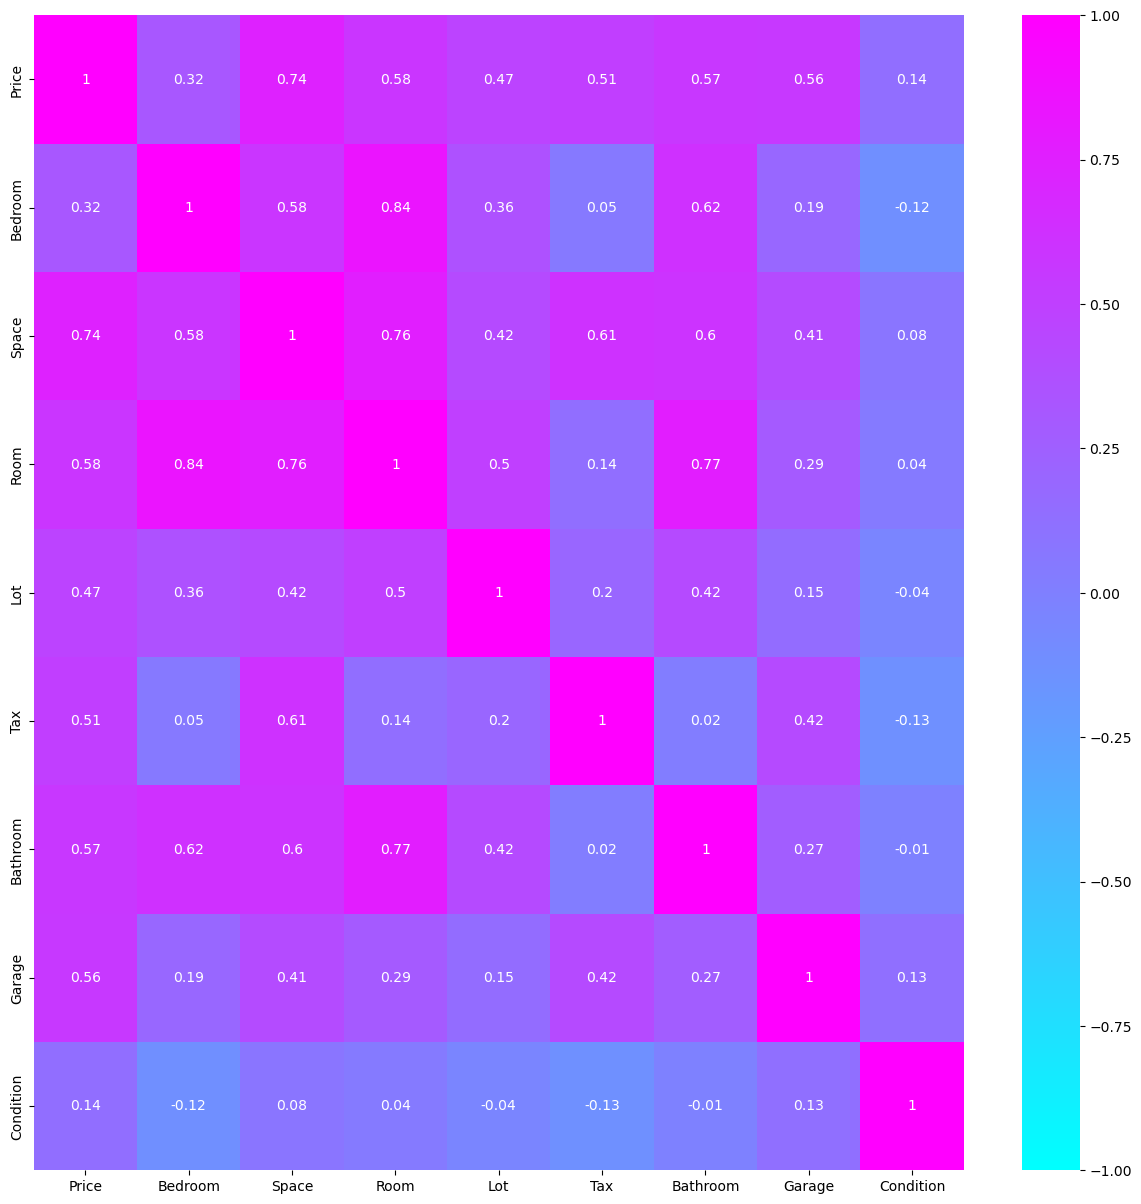

In [172]:
#Hartă de corelare
# Crearea figurii cu dimensiunea 15x15 inch
plt.figure(figsize=(15,15))

# Crearea unui heatmap pentru matricea de corelații 'corr_boston'
sns.heatmap(
    data=corr,   # datele care vor fi afișate în heatmap
    vmin=-1,            # valoarea minimă a culorilor (pentru scală)
    vmax=1,             # valoarea maximă a culorilor (pentru scală)
    center=0,           # centrul culorilor la 0 (pozitive vs negative)
    annot=True,         # afișează valorile numerice în celule
    cmap='cool'         # paleta de culori folosită
)

# Afișarea graficului
plt.show()


Din matricea de corelatie, putem observa ca urmatoarea coloana are o corelatie puternica cu variabila tinta Price, Space(0.74), iar negativ nu este in corelatie cu nicio alta variabila.
De asemenea variabilele Bedroom si Room sunt puternic corelate(0.84), Space cu Room(0,76), Room cu Bathroom(0.77),ceea ce poate provoca multicolinearitate în modelul de regresie. Pentru a evita redundanța și a crește stabilitatea coeficienților, se păstrează doar o variabilă din fiecare pereche puternic corelată și se elimină cealaltă, astfel pastrez Room si elimin bedroom si Bathroom.

In [173]:
cols = ['Bedroom', 'Bathroom']
nemodificat=df
df = df.drop(columns=cols)

# Verificăm dimensiunea noului dataframe
print("Dimensiunea inițială:", nemodificat.shape)
print("Dimensiunea după eliminare:",df.shape)

# Verificăm coloanele rămase
print("Coloane rămase:", df.columns.tolist())


Dimensiunea inițială: (128, 9)
Dimensiunea după eliminare: (128, 7)
Coloane rămase: ['Price', 'Space', 'Room', 'Lot', 'Tax', 'Garage', 'Condition']


In [174]:
# Variabila țintă (valoarea locuinței)
y = df_modificat['Price']
y.head()

0    53.0
1    55.0
2    56.0
3    58.0
4    64.0
Name: Price, dtype: float64

In [175]:
# Variabila independentă
X1 = df_modificat.drop('Price', axis=1)
X1.head()

,Bedroom,Space,Room,Lot,Tax,Bathroom,Garage_1.0,Garage_1.5,Garage_2.0,Condition_1.0
0,2.0,967.0,5.0,39.0,652.0,1.5,0.0,0.0,0.0,0.0
1,2.0,815.0,5.0,33.0,1000.0,1.0,0.0,0.0,1.0,1.0
2,3.0,900.0,5.0,35.0,897.0,1.5,1.0,0.0,0.0,0.0
3,3.0,1007.0,6.0,24.0,964.0,1.5,0.0,0.0,1.0,0.0
4,3.0,1100.0,7.0,50.0,1099.0,1.5,0.0,1.0,0.0,0.0


In [176]:
# Creare date de antrenare și de testare
from sklearn.model_selection import train_test_split

# Împărțirea datelor în set de antrenare și testare
X1_train, X1_test, y_train, y_test = train_test_split(
    X1, y, test_size=0.2, random_state=42)

print("Dimensiune set antrenare:", X1_train.shape, y_train.shape)
print("Dimensiune set test:", X1_test.shape, y_test.shape)

Dimensiune set antrenare: (102, 10) (102,)
Dimensiune set test: (26, 10) (26,)


In [177]:
from sklearn.linear_model import LinearRegression

# Crearea modelului
housing_model1 = LinearRegression()
# Antrenarea modelului pe datele de antrenare
housing_model1.fit(X1_train, y_train)

LinearRegression()

In [178]:
print("Coeficienți:", housing_model1.coef_) #coeficientul pentru variabila RM.
print("Intercept:", housing_model1.intercept_) #termenul liber din ecuația de regresie.

Coeficienți: [-1.39071001e+00  1.01513270e-02 -6.23396801e-01  2.70940246e-01
  4.85501022e-03  8.60303670e+00  5.53604605e+00  1.79813624e+01
  8.05899419e+00  3.87349505e+00]
Intercept: 22.600148085398594


In [179]:
# Prezicerea valorilor pentru setul de test
price_pred1 = housing_model1.predict(X1_test)
r2_1 = housing_model1.score(X1_test, y_test)
print('R-square: %.4f' % r2_1 )

R-square: 0.5690


In [180]:
# Evaluarea performanței modelului
from sklearn.metrics import mean_squared_error
import numpy as np

MSE1 = mean_squared_error( y_test, price_pred1)
print("MSE:", MSE1)

RMSE1 = np.sqrt(MSE1)
print("RMSE:", RMSE1)

MSE: 82.58261922537098
RMSE: 9.087497962881256


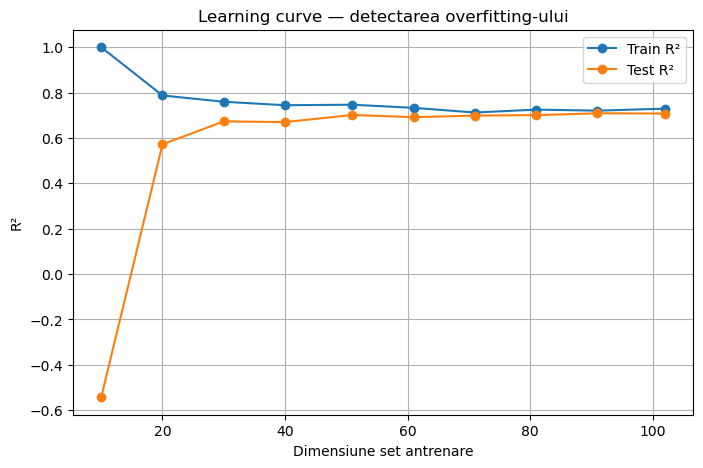

In [181]:
from sklearn.pipeline import make_pipeline

# Copiem datele și împărțim în set train/test
X_m = X1.copy()      # copiați caracteristicile
y_m = y             # ținta
X_train, X_test, y_train, y_test = train_test_split(
    X_m, y_m, test_size=0.2, random_state=42
)  # 80% train, 20% test


pipeline = make_pipeline(StandardScaler(), LinearRegression())


# --- Generarea Curbei de Învățare cu Pipeline-ul ---
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, # Utilizăm Pipeline-ul
    X_m, y_m, 
    cv=5, 
    scoring='r2',  
    train_sizes=np.linspace(0.1, 1.0, 10),)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'o-', label='Train R²')
plt.plot(train_sizes, test_mean, 'o-', label='Test R²')
plt.title('Learning curve — detectarea overfitting-ului')
plt.xlabel('Dimensiune set antrenare')
plt.ylabel('R²')
plt.legend()
plt.grid(True)
plt.show()

Se poate observa ca exiasta semne clare de overfitiing care incearca sa se regularizeze. Coeficientii arata ca Space are cel mai mare coeficienr, asta inseamna ca este cel mai important factor de predictie. Si Bedroom si BAthroom au coeficienti relativi mari. Performanta este 0.5690, asta inseamna ca aproximativ 56% din variatia pretului este explicata de modelul nostru liniar.

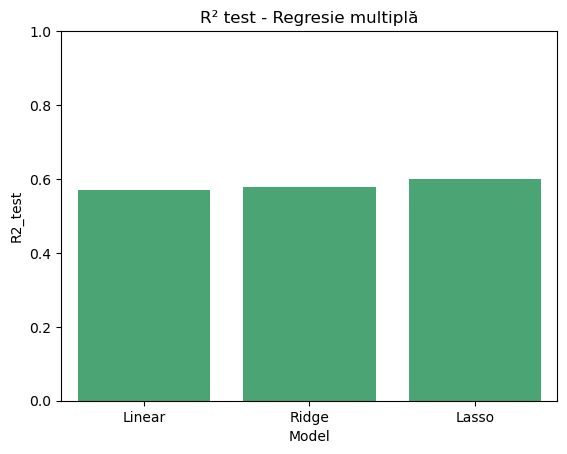

,Model,R2_test,MSE_test
0,Linear,0.568979,82.582619
1,Ridge,0.577938,80.866082
2,Lasso,0.600558,76.532073


In [182]:
#  Regularizare Ridge, Lasso, ElasticNet

# Standardizare date
scaler = StandardScaler()  
X_train_s = scaler.fit_transform(X_train)  # calculăm media și deviația standard pe train și transformăm
X_test_s = scaler.transform(X_test)        # transformăm test folosind media și std din train


# Antrenăm modelele
lin_multi = LinearRegression().fit(X_train_s, y_train)             # regresie liniară simplă
ridge_multi = Ridge(alpha=1.0).fit(X_train_s, y_train)            # Ridge cu alpha=1.0
lasso_multi = Lasso(alpha=0.1, max_iter=10000).fit(X_train_s, y_train)  # Lasso cu alpha=0.1 și max_iter mare pentru convergență


# Creăm o listă cu modelele și numele lor pentru iterații mai ușoare
models_multi = [('Linear', lin_multi), ('Ridge', ridge_multi), ('Lasso', lasso_multi)]


# Calculăm R² și MSE pe setul de test pentru fiecare model
r2_multi = [r2_score(y_test, m[1].predict(X_test_s)) for m in models_multi]          # R² test
mse_multi = [mean_squared_error(y_test, m[1].predict(X_test_s)) for m in models_multi]  # MSE test


# Creăm DataFrame pentru vizualizarea rezultatelor
df_r2_multi = pd.DataFrame({
    'Model': [m[0] for m in models_multi],  # numele modelelor
    'R2_test': r2_multi,                    # R² test
    'MSE_test': mse_multi                    # MSE test
})


# Vizualizăm R² pentru fiecare model
sns.barplot(data=df_r2_multi, x='Model', y='R2_test', color='mediumseagreen')  # barplot R²
plt.title('R² test - Regresie multiplă')  # titlu
plt.ylim(0,1)                              # limităm axa Y între 0 și 1
plt.show()
df_r2_multi

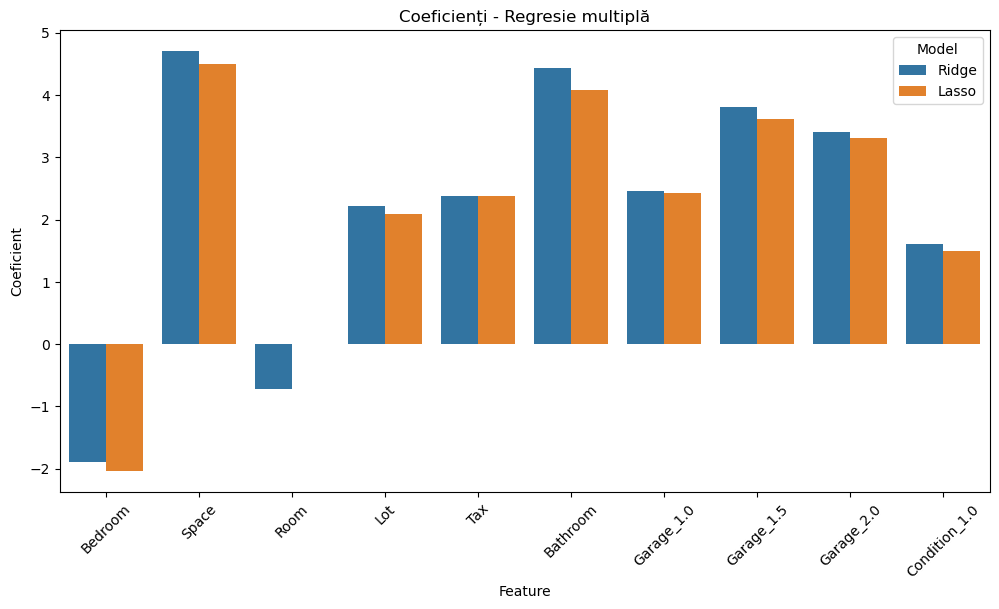

In [183]:
# Coeficienți barplot

# Creăm un DataFrame pentru coeficienți
# 'Feature' = numele caracteristicilor
# Coloanele Ridge, Lasso, ElasticNet = coeficienții fiecărui model
coef_df_multi = pd.DataFrame({
    'Feature': X1.columns,          # numele caracteristicilor
    'Ridge': ridge_multi.coef_,    # coeficienți Ridge
    'Lasso': lasso_multi.coef_,    # coeficienți Lasso
}).melt(
    id_vars='Feature',             # păstrăm coloana Feature ca identificator
    var_name='Model',              # numele modelului devine o coloană
    value_name='Coeficient'        # valorile coeficienților devin o coloană
)


# Vizualizare coeficienți
plt.figure(figsize=(12,6))        # setăm dimensiunea figurii
sns.barplot(
    data=coef_df_multi,
    x='Feature',                  # axa X = caracteristicile
    y='Coeficient',               # axa Y = valoarea coeficientului
    hue='Model'                   # culori diferite pentru fiecare model
)
plt.title('Coeficienți - Regresie multiplă')  # titlu grafic
plt.xticks(rotation=45)                        # rotim etichetele caracteristicilor pentru claritate
plt.show()

 Regularizarea controlează complexitatea prin penalizarea coeficienților mari. Modelul RIdge a oferit cea mai bvuna stabilitate.

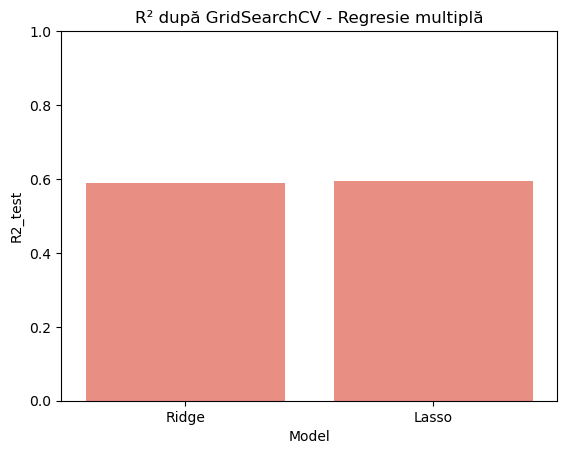

,Model,R2_test
0,Ridge,0.589469
1,Lasso,0.594604


In [184]:
# GridSearchCV pentru Ridge/Lasso/ElasticNet

# Definim grile de valori pentru hiperparametrii
param_grid_alpha = {'alpha': np.logspace(-3, 2, 20)}               # alpha pentru Ridge și Lasso
param_grid_enet = {'alpha': np.logspace(-3,1,10),                  # alpha pentru ElasticNet
                   'l1_ratio': np.linspace(0.1,0.9,9)}             # l1_ratio pentru ElasticNet

# Cross-validation cu 5 fold-uri
cv = KFold(n_splits=5, shuffle=True, random_state=42)              # împărțire aleatorie pentru evaluare stabilă

# Definim GridSearchCV pentru fiecare model
ridge_gs = GridSearchCV(Ridge(), param_grid_alpha, cv=cv, scoring='r2', n_jobs=-1)      # Ridge
lasso_gs = GridSearchCV(Lasso(max_iter=10000), param_grid_alpha, cv=cv, scoring='r2', n_jobs=-1)  # Lasso

# Antrenăm GridSearch pentru fiecare model pe setul standardizat de train
ridge_gs.fit(X_train_s, y_train)
lasso_gs.fit(X_train_s, y_train)


# Extragem cel mai bun estimator (parametri optimi) pentru fiecare model
best_ridge = ridge_gs.best_estimator_
best_lasso = lasso_gs.best_estimator_

# Calculăm R² pe setul de test folosind cei mai buni parametri
r2_grid_multi = [
    r2_score(y_test, best_ridge.predict(X_test_s)),
    r2_score(y_test, best_lasso.predict(X_test_s)),

]

# Creăm DataFrame pentru vizualizare R² după GridSearchCV
df_r2_grid_multi = pd.DataFrame({
    'Model':['Ridge','Lasso',], 
    'R2_test': r2_grid_multi
})

# Vizualizăm R² pentru fiecare model după GridSearch
sns.barplot(data=df_r2_grid_multi, x='Model', y='R2_test', color='salmon')
plt.title('R² după GridSearchCV - Regresie multiplă')  # titlu grafic
plt.ylim(0,1)                                           # limităm axa Y între 0 și 1
plt.show()
df_r2_grid_multi

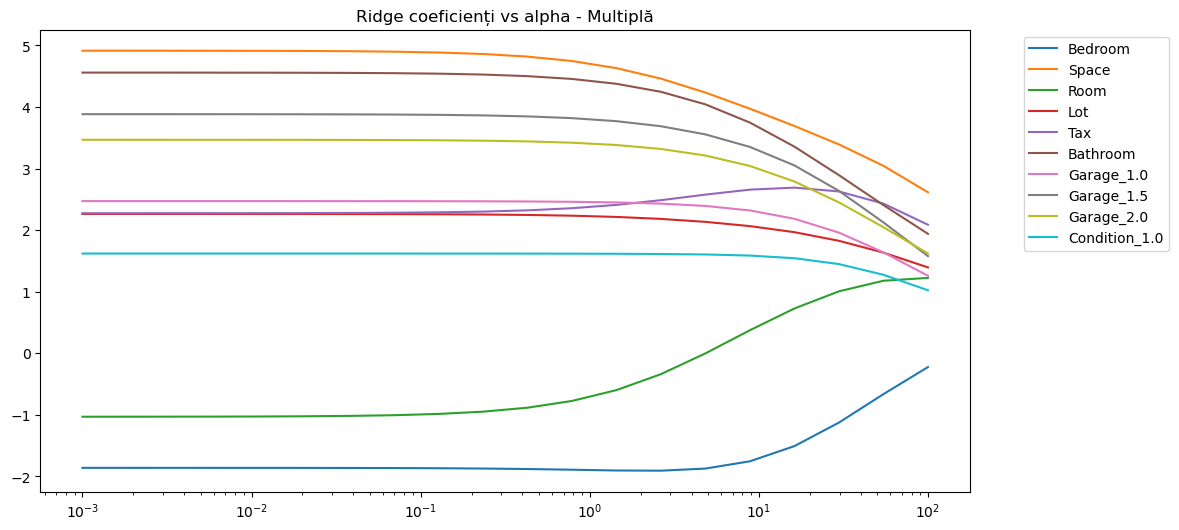

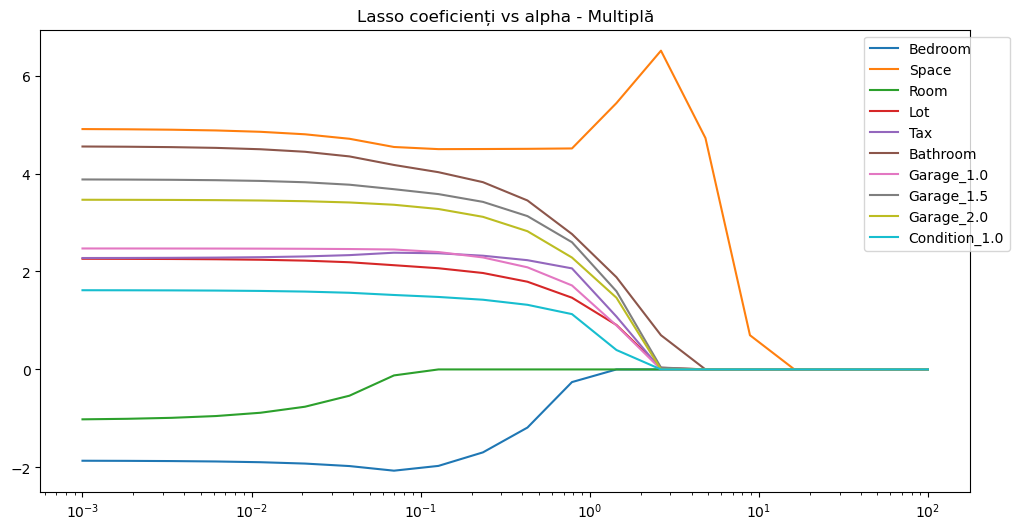

Ridge coef alpha=0.1 (multiplă): [-1.86819105  4.88392717 -0.98624999  2.25667442  2.28820757  4.54032775
  2.46873233  3.87141595  3.45858872  1.61844704]
Lasso coef alpha=0.1 (multiplă): [-1.96989758  4.49879189 -0.          2.0663165   2.37184553  4.02795488
  2.39703464  3.58042068  3.27618289  1.47992914]
ElasticNet coef alpha=0.1 (multiplă): [-1.61012134  4.16354197  0.          2.0619194   2.57256292  3.86257349
  2.28712084  3.39718105  3.05140938  1.57480566]


In [190]:

# Coeficienți vs alpha (multiplă)

# Definim un set de valori alpha pentru penalizare
alphas = np.logspace(-3,2,20)  # valori între 0.001 și 100

# Liste pentru coeficienți la fiecare alpha
ridge_coefs_multi, lasso_coefs_multi, enet_coefs_multi = [], [], []

# Valoare fixă pentru l1_ratio la ElasticNet
l1_ratio_val = 0.5


# Iterăm peste toate valorile de alpha
for a in alphas:
    # Antrenăm Ridge pentru alpha curent și salvăm coeficienții
    ridge_coefs_multi.append(Ridge(alpha=a).fit(X_train_s, y_train).coef_)
    
    # Antrenăm Lasso pentru alpha curent și salvăm coeficienții
    lasso_coefs_multi.append(Lasso(alpha=a, max_iter=10000).fit(X_train_s, y_train).coef_)
    
    # Antrenăm ElasticNet pentru alpha curent și salvăm coeficienții
    enet_coefs_multi.append(ElasticNet(alpha=a, l1_ratio=l1_ratio_val, max_iter=10000).fit(X_train_s, y_train).coef_)

# Transformăm listele în array-uri NumPy pentru manipulare ușoară
ridge_coefs_multi = np.array(ridge_coefs_multi)
lasso_coefs_multi = np.array(lasso_coefs_multi)
enet_coefs_multi = np.array(enet_coefs_multi)


# Grafic Ridge coeficienți vs alpha
plt.figure(figsize=(12,6))
for i, feat in enumerate(X1.columns):
    plt.plot(alphas, ridge_coefs_multi[:,i], label=feat)  # fiecare linie = un feature
plt.xscale('log')  # axa X pe scară logaritmică pentru alpha
plt.title('Ridge coeficienți vs alpha - Multiplă')
plt.legend(bbox_to_anchor=(1.05,1))  # legenda în afara graficului
plt.show()


# Grafic Lasso coeficienți vs alpha
plt.figure(figsize=(12,6))
for i, feat in enumerate(X1.columns):
    plt.plot(alphas, lasso_coefs_multi[:,i], label=feat)
plt.xscale('log')
plt.title('Lasso coeficienți vs alpha - Multiplă')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()



# Print coeficienți pentru alpha=0.1
idx = np.argmin(abs(alphas-0.1))  # găsim indexul celei mai apropiate valori alpha=0.1
print("Ridge coef alpha=0.1 (multiplă):", ridge_coefs_multi[idx])
print("Lasso coef alpha=0.1 (multiplă):", lasso_coefs_multi[idx])
print("ElasticNet coef alpha=0.1 (multiplă):", enet_coefs_multi[idx])




Pentru acest set de date regulasrizarea Ridge este cea mai buna, deoarece a obtinut un scor mai bun.